# Monthly Cloud-Free Composite with openEO

This notebook converts the Sentinel Hub
[Monthly Composite](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/monthly_composite/)
evalscript by **Nicolas Karasiak** into a reusable openEO User-Defined Process (UDP).

## Overview

In this notebook, we will:
1. Connect to an openEO backend service
2. Define an area of interest and a one-month window
3. Load Sentinel-2 L2A imagery for that month (with the Scene Classification Layer)
4. Build a single cloud-free composite by selecting, **per pixel**, the best
   (greenest / clearest) observation of the month
5. Apply the original enhanced natural-color stretch and export the result as a
   reusable openEO process

## What the monthly composite does

The original evalscript walks every Sentinel-2 acquisition of the last ~31 days
(`mosaicking: "ORBIT"` + a `preProcessScenes` 31-day filter) and, for each output
pixel, keeps the **single best observation** rather than averaging. "Best" is the
clearest land sample, chosen as the date with the **maximum `B08 / B03` (NIR/Green)
ratio** — a greenest-pixel criterion that favours vegetated, haze-free, snow-free
samples. It then renders that observation with an enhanced natural-color stretch.

This is the classic **Best Available Pixel (BAP) / greenest-pixel composite**
technique, which we reproduce with standard openEO processes.

### How the conversion maps to openEO

| Original (evalscript) | openEO conversion |
| --- | --- |
| `mosaicking: "ORBIT"` + 31-day `preProcessScenes` filter | one-month `temporal_extent` on `load_collection` |
| Blue / NDSI / red brightness "clearness" heuristics that pick clear samples | Scene Classification Layer (SCL) mask + `eo:cloud_cover` scene filter |
| `indexOfMaxRatio(B08, B03)` — pick the date with max NIR/Green ratio | per-pixel greenest-pixel selection via `apply_dimension("t", max-of-ratio)` + `mask` |
| Enhanced color `R=2.8·B04+0.1·B05`, `G=2.8·B03+0.15·B08`, `B=2.8·B02` | the same band math via `apply_dimension("bands", array_create(...))` |
| Per-pixel water (`max B02/B08`) and snow (median) special cases | **simplified**: a single greenest-pixel ranking is applied everywhere (see *Limitations*) |


## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/monthly_composite/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and
visualization.


In [1]:
import rioxarray
import matplotlib.pyplot as plt
from openeo.processes import array_create

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

Load algorithm parameters from the co-located parameter file and connect to an
openEO backend. We use the **Copernicus Data Space Ecosystem (CDSE)** because the
composite needs every Sentinel-2 acquisition of the target month.


In [2]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = "monthly_composite"

# Initialize parameter manager
param_manager = ParameterManager('monthly_composite.params.py')

# Display available options using the built-in helper
param_manager.print_options("monthly composite algorithm")

Available parameter sets for monthly composite algorithm:
  1. west_corsica_france: West Corsica, France
  2. po_valley_cropland_italy: Po Valley Cropland, Italy
  3. brittany_france: Brittany Coast, France

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [3]:
# Connect using a parameter set for a specified location on the CDSE endpoint.
# CDSE is required here because the full Sentinel-2 archive for the month is needed.
connection, current_params = param_manager.quick_connect(
    param_set="west_corsica_france",
    endpoint="ds_development",
)

🔄 Connecting to ds_development...
📍 Using parameter set: west_corsica_france
✅ Successfully connected to ds_development
✅ Parameters loaded and mapped for: West Corsica, France
🔄 Parameters mapped for endpoint ds_development:
  bands: ['B02', 'B03', 'B04', 'B05', 'B08', 'SCL'] -> ['B02_10m', 'B03_10m', 'B04_10m', 'B05_20m', 'B08_10m', 'SCL_20m']
  collection: SENTINEL2_L2A -> sentinel-2-l2a


## Load Sentinel-2 Data

Load Sentinel-2 L2A (atmospherically corrected) data over the one-month window. We
need:

- **B02** (492 nm, Blue), **B03** (560 nm, Green), **B04** (665 nm, Red): visible bands
- **B05** (704 nm, Red Edge 1) and **B08** (833 nm, NIR): used by the enhanced
  color stretch and the `B08/B03` greenest-pixel ranking
- **SCL**: Scene Classification Layer, used for cloud/shadow masking

`time` and `bounding_box` are passed as **`Parameter` objects** so the exported
process graph keeps `{"from_parameter": ...}` references and stays reusable as a
UDP. The scene-level `eo:cloud_cover` threshold is baked from the selected set.


In [4]:
# Load Sentinel-2 data across the one-month window.
# Runtime knobs (time, bounding_box) are wired as Parameter refs; collection and
# bands are intrinsic to the algorithm and passed as concrete defaults.
s2cube = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=current_params["time"],
    spatial_extent=current_params["bounding_box"],
    bands=current_params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
    },
)

print("✅ Sentinel-2 data loaded successfully!")

✅ Sentinel-2 data loaded successfully!


## Cloud and Shadow Masking (SCL)

The original evalscript reimplements its own clearness logic (blue-band and NDSI
thresholds) because `ORBIT` mosaicking hands it raw multi-temporal samples. In
openEO we use the idiomatic **Scene Classification Layer (SCL)** instead. We drop
pixels classified as cloud shadow (3), cloud medium probability (8), cloud high
probability (9), thin cirrus (10), and snow/ice (11).


In [5]:
# Build a mask from the SCL band: True where we want to discard the pixel.
# Resolve the SCL band by prefix; the exact name varies by backend (e.g. "SCL"
# on CDSE, "SCL_20m" elsewhere).
scl_band = next(b for b in s2cube.metadata.band_names if b.lower().startswith("scl"))
scl = s2cube.band(scl_band)
invalid = (scl == 3) | (scl == 8) | (scl == 9) | (scl == 10) | (scl == 11)

# mask() removes pixels where the mask is non-zero (True).
s2_masked = s2cube.mask(invalid)

## Per-Pixel "Greenest Pixel" Selection

The heart of the original script is `indexOfMaxRatio(B08, B03)`: for each pixel it
keeps the acquisition of the month with the **largest NIR/Green ratio**. A high
`B08/B03` ratio marks dense, healthy vegetation and, just as importantly, a clear
atmosphere — haze, thin cloud and shadow all depress NIR relative to green. This is
the standard **greenest-pixel / Best Available Pixel** compositing criterion.

We compute the ratio per acquisition, then build a temporal mask that is `True`
everywhere **except** at the date of the maximum ratio. Masking the data with it
and reducing over time leaves exactly the best observation per pixel.


In [ ]:
# Greenest-pixel ranking score per acquisition: NIR / Green (B08 / B03).
# Resolve band names by prefix since backends may rename them (e.g. "B08_10m").
nir_band = next(b for b in s2_masked.metadata.band_names if b.lower().startswith("b08"))
green_band = next(b for b in s2_masked.metadata.band_names if b.lower().startswith("b03"))
rank = s2_masked.band(nir_band) / s2_masked.band(green_band)


# For each pixel, mark every date that is NOT the maximum-ratio date.
# (Within the callback `ratio` is the array of values along the time axis.)
def keep_only_max(ratio):
    return ratio.array_apply(lambda x: x != ratio.max())


# rank_mask is True where a date should be dropped (everything but the best one).
# No-data (cloud-masked) samples are ignored by max(), so they never win.
rank_mask = rank.apply_dimension(dimension=current_params["time_dimension"], process=keep_only_max)

## Enhanced Natural-Color Stretch

The original renders the selected sample with a mild vegetation-boosting natural
color stretch (the `colorMap` expression):

- **R** = `gain · B04 + 0.1 · B05`
- **G** = `gain · B03 + 0.15 · B08`
- **B** = `gain · B02`

where `gain` is the original `2.8` multiplier. The small red-edge / NIR additions
warm up vegetation. Bands are first divided by `reflectance_scale` (10000 on CDSE)
to recover 0-1 reflectance, matching the original's input range.


In [7]:
gain = current_params["gain"].default
scale = current_params["reflectance_scale"]  # 10000.0 on CDSE, 1.0 if already reflectance

# Band index order matches the `bands` parameter: B02, B03, B04, B05, B08, SCL.
def enhanced_rgb(data):
    b02 = data[0] / scale
    b03 = data[1] / scale
    b04 = data[2] / scale
    b05 = data[3] / scale
    b08 = data[4] / scale
    red = gain * b04 + 0.1 * b05
    green = gain * b03 + 0.15 * b08
    blue = gain * b02
    return array_create([red, green, blue])


# Apply the stretch per acquisition, producing a 3-band (R, G, B) cube over time.
rgb = s2_masked.apply_dimension(dimension=current_params["bands_dimension"], process=enhanced_rgb)

# Keep only the greenest-pixel date per pixel, then collapse the time axis.
composite = rgb.mask(rank_mask).reduce_dimension(dimension="t", reducer="max")

## Apply and Export

Save the 3-band enhanced RGB composite as a GeoTIFF.


In [8]:
composite_result = composite.save_result("GTiff")

## Download and Visualize Results

Download the composite for the selected area and display it as an enhanced
natural-color image. Reflectance is clipped to `[0, 1]` for display, reproducing
the original `stretch(val, 0, 1)` behaviour.


In [9]:
# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialize them with the current parameter set's defaults before download.
# The underlying parameterized graph is preserved for the UDP export cell below.
filename = f"{_algorithm_id}_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.tif"

resolved = param_manager.resolve(composite_result, current_params)
resolved.download(filename)

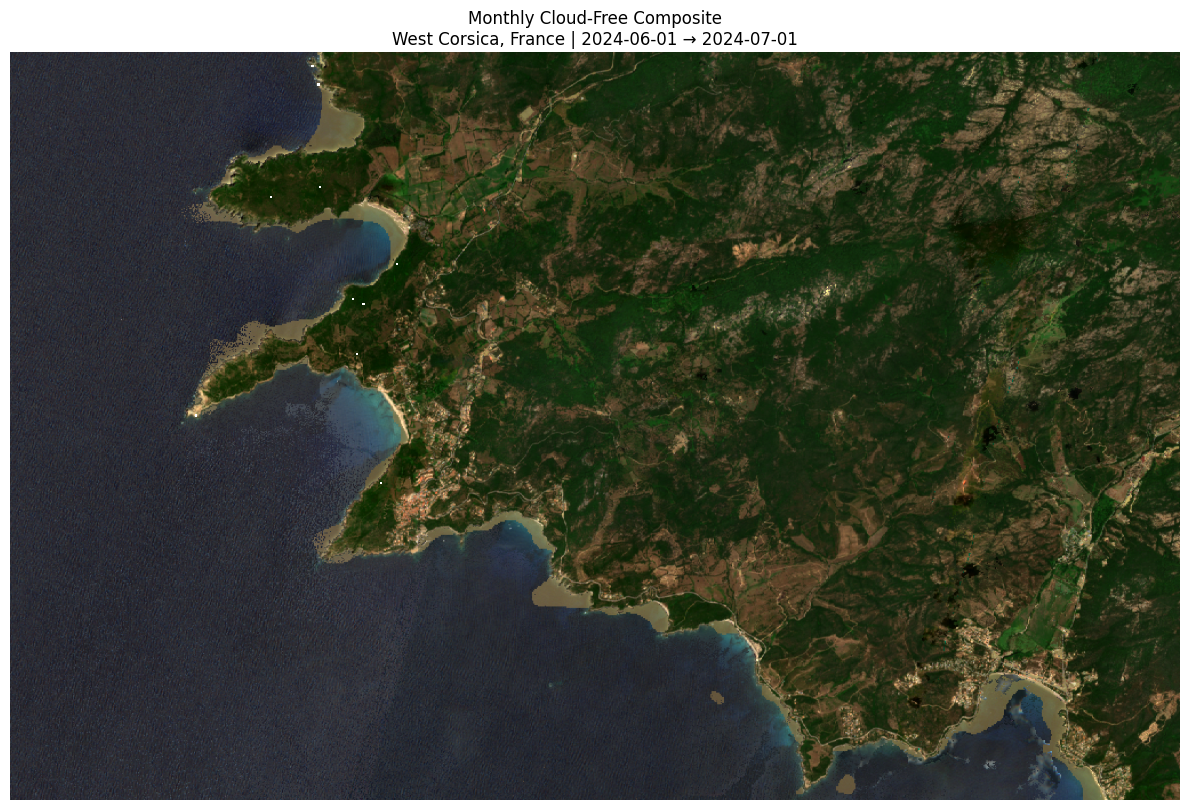

In [10]:
# Open the 3-band result and display it as an RGB image.
ds = rioxarray.open_rasterio(filename)

# Move the band axis last and clip reflectance to [0, 1] for display.
rgb_img = ds.transpose("y", "x", "band").values
rgb_img = rgb_img.clip(0, 1)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(
    rgb_img,
    extent=[ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()],
)
ax.set_title(
    f"Monthly Cloud-Free Composite\n{current_params['location_name']} | "
    f"{current_params['time'].default[0]} → {current_params['time'].default[1]}",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Interpretation Guide and Limitations

### Reading the result

The output is a single cloud-free, enhanced natural-color view of the month. Each
pixel comes from the clearest, greenest acquisition available within the window, so
clouds, haze and shadows are largely removed even where no single scene was clear.

### Limitations and differences from the original

- **Water and snow special cases are not reproduced.** The original switches the
  ranking to `max(B02/B08)` over open water and falls back to a median of snow
  samples. Here a single greenest-pixel (`max B08/B03`) ranking is applied
  everywhere; SCL masking already removes most snow/ice, but bright water bodies
  may pick a less ideal sample. This could be added as a per-pixel conditional
  refinement.
- **Clearness heuristics replaced by SCL.** The blue-band and NDSI thresholds the
  original uses to identify clear samples are replaced by the Scene Classification
  Layer, which is the idiomatic openEO approach.
- **Ties.** If several dates share the maximum ratio for a pixel, `reduce_dimension`
  with `max` keeps the brightest of them.
- **Compute cost.** Like the original, the composite ingests every acquisition of
  the month; keep the area of interest modest (e.g. a few tens of km).


In [11]:
# Create a directory to export images, UDP, and OGC API records
from pathlib import Path

_repo_root = next(p for p in Path.cwd().parents if (p / "notebooks").exists())
_alg_dir = _repo_root / "algorithm_registration" / _algorithm_id
_records_dir = _alg_dir / "records"
_udp_dir = _alg_dir / "openeo_udp"

_records_dir.mkdir(parents=True, exist_ok=True)
_udp_dir.mkdir(parents=True, exist_ok=True)

In [12]:
# Export the process graph for reuse as a parameterized UDP
import json

process_graph = {
    "process_graph": composite_result.flat_graph(),
    "parameters": [
        current_params["time"].to_dict(),
        current_params["bounding_box"].to_dict(),
        current_params["cloud_cover"].to_dict(),
        current_params["gain"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "Monthly cloud-free greenest-pixel composite from Sentinel-2 imagery using openEO.",
    "description": (
        "Builds a single cloud-free RGB composite from one month of Sentinel-2 L2A "
        "imagery by selecting, per pixel, the acquisition with the maximum B08/B03 "
        "(NIR/Green) ratio after SCL cloud masking, then applying an enhanced "
        "natural-color stretch. Converted from the Sentinel Hub Monthly Composite "
        "evalscript by Nicolas Karasiak."
    ),
}

with open(f"{_udp_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(process_graph, f, indent=2)

print(f"Process graph exported to {_udp_dir}/{_algorithm_id}.json")
print(f"Process ID: {_algorithm_id}")

Process graph exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/monthly_composite/openeo_udp/monthly_composite.json
Process ID: monthly_composite


In [13]:
# Export necessary metadata to register the process graph in APEx Algorithm Catalogue
_nb_href = f"{(Path.cwd() / f'{_algorithm_id}.ipynb').relative_to(_repo_root)}"

metadata = {
    "id": _algorithm_id,
    "title": "Monthly Cloud-Free Composite",
    "preview_title": "Monthly Cloud-Free Composite",
    "description": (
        "Builds a single cloud-free RGB composite from one month of Sentinel-2 L2A "
        "imagery by selecting, per pixel, the clearest greenest acquisition "
        "(maximum B08/B03 ratio after SCL cloud masking) and applying an enhanced "
        "natural-color stretch."
    ),
    "keywords": ["Composite", "Mosaic", "Cloud-free", "Best Available Pixel", "Sentinel-2"],
    "themes": ["IMAGERY", "REMOTE SENSING", "Sentinel-2 MSI"],
    "created": "2026-06-22T00:00:00Z",
    "updated": "2026-06-22T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": "CDSE openEO Federation",
    "openeo_backend_url": "https://openeofed.dataspace.copernicus.eu",
    "notebook_github_location": _nb_href,
    "collection_id": "SENTINEL2_L2A",
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/monthly_composite/",
        "authors": ["Nicolas Karasiak"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
        "citation": None,
    },
}

with open(f"{_records_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Catalogue record exported to {_records_dir}/{_algorithm_id}.json")

Catalogue record exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/monthly_composite/records/monthly_composite.json


## References and Attribution

**Original Script:** [Monthly Composite](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/monthly_composite/)

**Author:** Nicolas Karasiak

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### openEO Conversion
- **Conversion Date**: 22 June 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
- **Backend Tested**: CDSE (Copernicus Data Space Ecosystem)
- **License**: CC-BY-SA-4.0


## Conclusion

This notebook converts the Monthly Composite algorithm into an openEO User-Defined
Process. The implementation:

✅ **Reproduces the best-pixel logic** of the original `ORBIT` mosaicking and
`indexOfMaxRatio(B08, B03)` selection using `apply_dimension` over time plus a
mask-and-reduce step.

✅ **Uses idiomatic openEO cloud masking** via the Scene Classification Layer
instead of the original blue/NDSI clearness heuristics.

✅ **Preserves the enhanced natural-color stretch** (`gain·B04+0.1·B05`,
`gain·B03+0.15·B08`, `gain·B02`).

✅ **Follows openEO standards** with an exported, parameterized process graph and
catalogue metadata.

### Key conversion notes
- `time` and `bounding_box` are exposed as runtime UDP parameters; `collection`
  and `bands` are intrinsic to the algorithm.
- The per-pixel water and snow special cases are simplified to a single
  greenest-pixel ranking (see *Limitations*).
